In [ ]:
!jupyter nbconvert --to html /content/group_18_credit_card_defaulters.ipynb

[NbConvertApp] Converting notebook /content/group_18_credit_card_defaulters.ipynb to html
[NbConvertApp] Writing 1283143 bytes to /content/group_18_credit_card_defaulters.html


<h1><center><b>Credit Card Defaulters</b></center></h1>

<h2><b>Group # 18</b></h2>
<ul>
  <li> Saad Qadeer 2022-10-0209 </li>
  <li> Khawaja Junaid 2022-10-0072 </li>
  <li> Muhammad Bilal 2022-10-0224 </li>
</ul>


#**Exploratory Data Analysis (EDA)**
This deliverable will be focused towards getting familiar with the data. For thatyou will have to get your hands dirty with the data. This will consist of initial data exploration, visualizations etc. This could include but not limited to the following points:

• Data Preprocessing (Identifying duplicate data and removing it, finding
missing values and replacing them by an appropriate strategy, normalizing
the data)

• Calculating and visualization of summary statistics (consider boxplots, bar
graphs)

• Finding correlation between attributes.

• Finding out dependence between categorical and numerical attributes.

• Using graphs to visualize the data (at least 5-6 graphs representing
meaningful information)


<b>Importing Libraries</b>

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import f_oneway

<b>Mouting Google Drive</b>



In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<b>Loading dataset</b>

In [ ]:
df =pd.read_csv("drive/My Drive/CS 432 - Project/Group#18/Phase 1/credit_card_defaulters.csv")

In [ ]:
df

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,1.0,2,Business Entity Type 3
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,State servant,Higher education,Married,House / apartment,Core staff,2.0,1,School
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,1.0,2,Government
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,2.0,2,Business Entity Type 3
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,1.0,2,Religion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,Working,Secondary / secondary special,Separated,With parents,Sales staff,1.0,1,Services
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,Pensioner,Secondary / secondary special,Widow,House / apartment,NaN,1.0,2,XNA
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,Working,Higher education,Separated,House / apartment,Managers,1.0,3,School
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers,2.0,2,Business Entity Type 1


# **Data Preprocessing**


## **Identifying duplicate data**

Using the .duplicated() function, we get a boolena data frame that indicates duplicate values that are present in the original data base.

In [ ]:
bool_series = df.duplicated()
bool_series

0         False
1         False
2         False
3         False
4         False
          ...  
307506    False
307507     True
307508    False
307509    False
307510    False
Length: 307511, dtype: bool

In [ ]:
pd.DataFrame(bool_series.value_counts()).rename(columns={0:"Count"})

,Count
False,297591
True,9920


As returned by the above function, there are almost 9000 duplicate values present in the data base. From these duplicated we will keep the original value and remove the dupliactes.

# **Removing Duplicate Data**

In [ ]:
df.drop_duplicates(keep = False, inplace = True)

In [ ]:
df.shape

(291858, 16)

# **Identifying Missing Values**

In [ ]:
missingValues = df.notnull()

In [ ]:
missingValues

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307504,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True
307506,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
307508,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
307509,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [ ]:
def missingValueAttributes():
  attributesWithMissingValues = list()
  for i in missingValues.columns:
    for j in missingValues[i]:
      if j == False:
        attributesWithMissingValues.append(i)
        break

The following code displays all the attributes that were found to contain missing values.

In [ ]:
display(pd.DataFrame(attributesWithMissingValues).rename(columns={0:"Attribute Name"}))

,Attribute Name
0,CODE_GENDER
1,INCOME_TOTAL
2,CREDIT
3,OCCUPATION_TYPE
4,FAM_MEMBERS


The following peice of code shows how many missing values were found in each of the above mentioned attributes.

In [ ]:
for i in attributesWithMissingValues:
  display(pd.DataFrame(missingValues[i].value_counts()))
  print('\n')

,CODE_GENDER
True,291856
False,2


,INCOME_TOTAL
True,291832
False,26


,CREDIT
True,291850
False,8


,OCCUPATION_TYPE
True,207892
False,83966


,FAM_MEMBERS
True,291856
False,2


#**Replacing Missing Values**

To replace the missing values we are using the mode fill method.

In [ ]:
for i in df.columns:
  try:
    df[i] = df[i].fillna(df[i].mode()[0])
  except:
    pass

#**Counting Missing Values after Replacing them**

In [ ]:
missingValues = df.notnull()
attributesWithMissingValues = list()
for i in missingValues.columns:
  for j in missingValues[i]:
    if j == False:
      attributesWithMissingValues.append(i)
      break

if len(attributesWithMissingValues) == 0:
  print('Success: No more missing values were found!')
else:
  print('The following attributes still have missing values: ')
  print(attributesWithMissingValues)

Success: No more missing values were found!


#**Dealing with Corrputed Values**

When going through the unique values for each column, we found that the gender column has a null values but with a different representation, so we had to deal with that case seperately. Null values that are usually represented by NA were shown by XNA in the CODE_GENDER columns.

In [ ]:
df['CODE_GENDER'] = df['CODE_GENDER'].replace(['XNA'], df['CODE_GENDER'].mode()[0])

In [ ]:
pd.DataFrame(df['CODE_GENDER'].value_counts())

,CODE_GENDER
F,189364
M,102494


#**Data Visualizations**

<h3><b>Bar Graphs</b></h3>

<h5><b>1. Target - Defaulter v/s Non-Defaulter</b></h5>

In [ ]:
target = pd.DataFrame(df['TARGET'].value_counts())
target

,TARGET
0,267185
1,24673


Text(0, 0.5, 'Count')

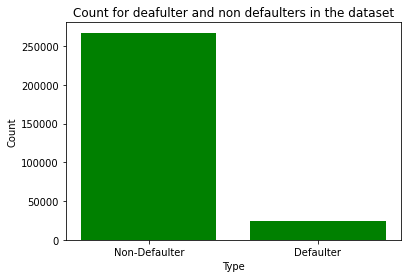

In [ ]:
labels = ['Non-Defaulter', 'Defaulter']
plt.bar(labels, target['TARGET'], color='green')
plt.title('Count for deafulter and non defaulters in the dataset')
plt.xlabel('Type')
plt.ylabel('Count')

<h5><b>2. Gender</b></h5>

In [ ]:
gender =pd.DataFrame(df['CODE_GENDER'].value_counts())
gender

,CODE_GENDER
F,189364
M,102494


Text(0, 0.5, 'Count')

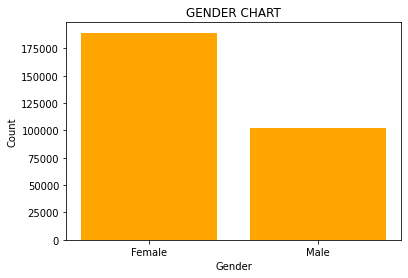

In [ ]:
labels = ['Female', 'Male']
plt.bar(labels, gender['CODE_GENDER'], color='orange')
plt.title('GENDER CHART')
plt.xlabel('Gender')
plt.ylabel('Count')

As shown by the results, we see that there is gender inbalance in the data, the number of females in the dataset is approximately double the number of males that are present in the data set.

<h5><b>3. Family Status</b></h5>

In [ ]:
family = pd.DataFrame(df['FAMILY_STATUS'].value_counts()).rename(columns={'FAMILY_STATUS':'Count'})
family.index.name = 'Status'
family

,Count
Status,
Married,185256
Single / not married,44151
Civil marriage,29280
Separated,19274
Widow,13895
Unknown,2


Text(0, 0.5, 'Count')

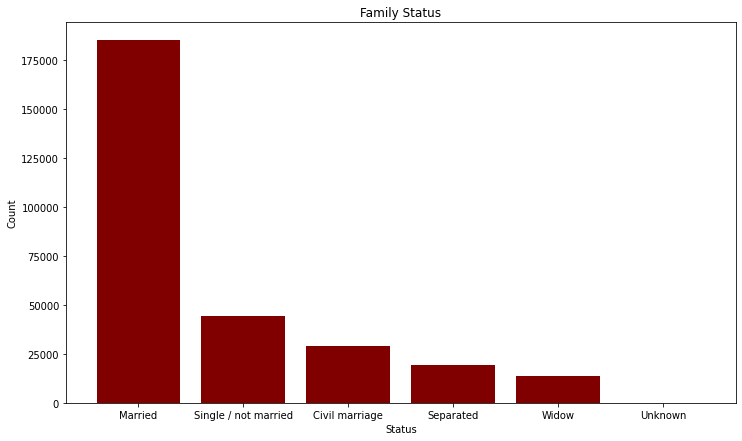

In [ ]:
fig = plt.figure(figsize =(12, 7))
plt.bar(family.index, family['Count'], color='maroon')
plt.title('Family Status')
plt.xlabel('Status')
plt.ylabel('Count')

<h5><b>4. Contract Type</b></h5>

In [ ]:
contract = pd.DataFrame(df['NAME_CONTRACT_TYPE'].value_counts())
contract

,NAME_CONTRACT_TYPE
Cash loans,264598
Revolving loans,27260


Text(0, 0.5, 'Count')

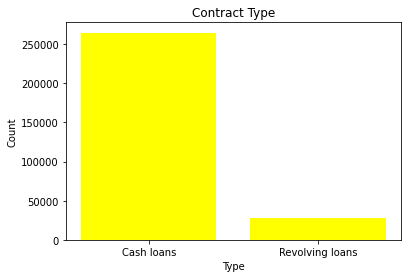

In [ ]:
plt.bar(contract.index, contract['NAME_CONTRACT_TYPE'], color='yellow')
plt.title('Contract Type')
plt.xlabel('Type')
plt.ylabel('Count')

As seen by the above graph, we see that are two type of loan facilities, cash loans and revolving loans.  Arevolving loan can be defined as: A committed loan facility allowing a borrower to borrow (up to a limit), repay and re-borrow loans. And A cash basis loan is one in which interest is recorded as earned when payment is collected. We see that are is a significant difference between the types of loans.

<h5><b>5. Cars</b></h5>

In [ ]:
cars = pd.DataFrame(df['FLAG_OWN_CAR'].value_counts())
cars

,FLAG_OWN_CAR
N,189565
Y,102293


In [ ]:
gender

,CODE_GENDER
F,189364
M,102494


As seen by the results above the ratio of Female : Male is approximately similar to No Car Owned : Car Owned. There might be a relationship existing between the two attributes and this may be useful to note when conduction analysis on the relationship between different attributes.  

Text(0, 0.5, 'Count')

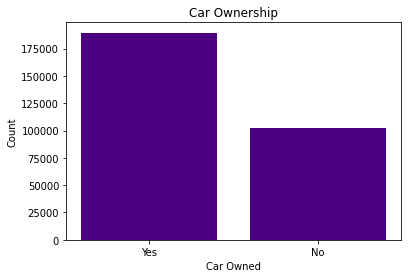

In [ ]:
plt.bar(['Yes', 'No'], cars['FLAG_OWN_CAR'], color='indigo')
plt.title('Car Ownership')
plt.xlabel('Car Owned')
plt.ylabel('Count')

<h5><b>6. Realty Owned </b></h5>

In [ ]:
assets = pd.DataFrame(df['FLAG_OWN_REALTY'].value_counts())
assets

,FLAG_OWN_REALTY
Y,200218
N,91640


In [ ]:
cars

,FLAG_OWN_CAR
N,189565
Y,102293


Using the above displayed data frames for Owned Realty and Cars Owned, we see that about 200,000 people own a house or a flat but out of those 200,000 only about 100,000 people own a car i.e. only 50% of the people who own a house also own a car.

Text(0, 0.5, 'Count')

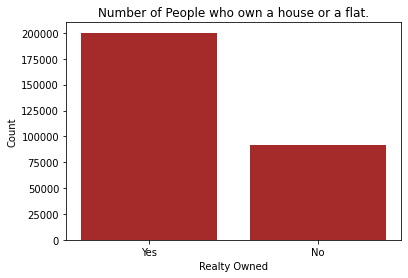

In [ ]:
plt.bar(['Yes', 'No'], assets['FLAG_OWN_REALTY'], color='brown')
plt.title('Number of People who own a house or a flat.')
plt.xlabel('Realty Owned')
plt.ylabel('Count')

# **Summary statistics**

In [ ]:
df.describe()

,TARGET,CNT_CHILDREN,INCOME_TOTAL,CREDIT,FAM_MEMBERS,REGION_RATING_CLIENT
count,291858.000000,291858.000000,2.918580e+05,2.918580e+05,291858.000000,291858.000000
mean,0.084538,0.435695,1.712900e+05,6.047812e+05,2.170771,2.052683
std,0.278193,0.733140,2.428716e+05,4.056518e+05,0.922183,0.518429
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1.000000,1.000000
25%,0.000000,0.000000,1.125000e+05,2.725200e+05,2.000000,2.000000
50%,0.000000,0.000000,1.575000e+05,5.212800e+05,2.000000,2.000000
75%,0.000000,1.000000,2.025000e+05,8.140410e+05,3.000000,2.000000
max,1.000000,19.000000,1.170000e+08,4.050000e+06,20.000000,3.000000


### <b>Summary stats for defaulters</b>

In [ ]:
df_defaulter=df[df['TARGET']==1]
df_defaulter[['CNT_CHILDREN','INCOME_TOTAL','CREDIT','FAM_MEMBERS','REGION_RATING_CLIENT']].describe()

,CNT_CHILDREN,INCOME_TOTAL,CREDIT,FAM_MEMBERS,REGION_RATING_CLIENT
count,24673.000000,2.467300e+04,2.467300e+04,24673.000000,24673.000000
mean,0.466259,1.658624e+05,5.581005e+05,2.183520,2.154096
std,0.758228,7.489587e+05,3.468626e+05,0.952823,0.506128
min,0.000000,2.565000e+04,4.500000e+04,1.000000,1.000000
25%,0.000000,1.125000e+05,2.844000e+05,2.000000,2.000000
50%,0.000000,1.350000e+05,4.975200e+05,2.000000,2.000000
75%,1.000000,2.025000e+05,7.341660e+05,3.000000,2.000000
max,11.000000,1.170000e+08,4.027680e+06,13.000000,3.000000


### <b>Summary stats for non defaulters</b>

In [ ]:
df_nondefaulter=df[df['TARGET']==0]
df_nondefaulter[['CNT_CHILDREN','INCOME_TOTAL','CREDIT','FAM_MEMBERS','REGION_RATING_CLIENT']].describe()

,CNT_CHILDREN,INCOME_TOTAL,CREDIT,FAM_MEMBERS,REGION_RATING_CLIENT
count,267185.000000,2.671850e+05,2.671850e+05,267185.000000,267185.000000
mean,0.432872,1.717912e+05,6.090919e+05,2.169594,2.043318
std,0.730717,1.123972e+05,4.103892e+05,0.919295,0.518552
min,0.000000,2.565000e+04,4.500000e+04,1.000000,1.000000
25%,0.000000,1.125000e+05,2.701260e+05,2.000000,2.000000
50%,0.000000,1.575000e+05,5.212800e+05,2.000000,2.000000
75%,1.000000,2.025000e+05,8.248230e+05,3.000000,2.000000
max,19.000000,1.800009e+07,4.050000e+06,20.000000,3.000000


#**Box Plots**

The above summary stats can be better visualized with box plots for the two cateogories as well as with their particular gender. The box plot will also help us to identify possible outliers in the data.


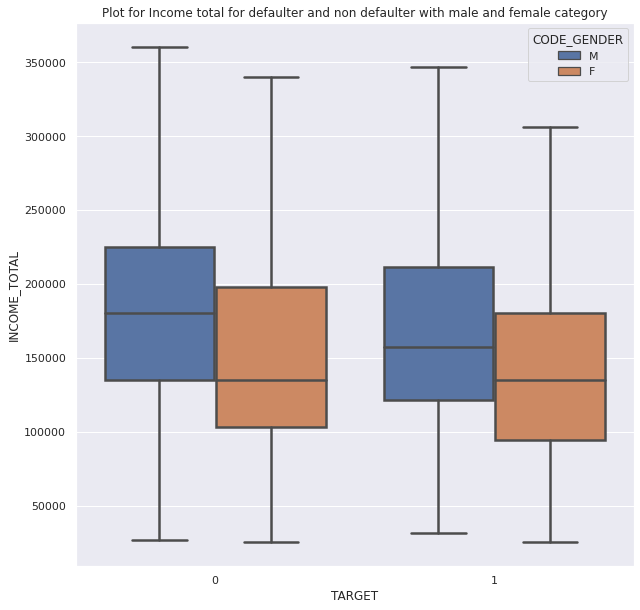

In [ ]:
ax = sns.boxplot(x="TARGET", y="INCOME_TOTAL", hue="CODE_GENDER", data=df, linewidth=2.5,showfliers=False).set(title='Plot for Income total for defaulter and non defaulter with male and female category')
ax = sns.set(rc={'figure.figsize':(10,10)})


### There were extreme outliers for the defaulter category which are not being shown in the plot
The plot above shows that the Target=1 (defaulter) have a lower mean income as
compared to the non defaulters which would mean that they are unable to pay their loans, apart from that it can also be seen female defaulter to have a lower mean income for both categories.

For the other categories we see that the nondefaulters:


1.    Have a lower region rating which means the defaulters live in a region with higher rating meaning that the cost of living there would be higher as well.
2.   Have a lower mean for count of children according to the summary statistics, meaning less to spend on other members.



<h1><b>Encoding the Data</b></h1>

In [ ]:
copy = df.copy()

In [ ]:
copy.columns

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'INCOME_TOTAL', 'CREDIT',
       'NAME_INCOME_TYPE', 'EDUCATION_TYPE', 'FAMILY_STATUS', 'HOUSING_TYPE',
       'OCCUPATION_TYPE', 'FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'ORGANIZATION_TYPE'],
      dtype='object')

The below code creates a mapping from a string to a an integer for all the attributes that are ordinal in nature.

In [ ]:
map_contract = {'Cash loans': 0, 'Revolving loans':1}
map_gender = {'F':0, 'M':1}
map_car = {'N': 0, 'Y': 1}
map_realty = {'N': 0, 'Y': 1}
map_income = {'Working':0, 'Commercial associate': 1, 'Pensioner': 2, 'State servant': 3, 'Unemployed':4, 'Student':5, 'Businessman': 6, 'Maternity leave': 5}
map_education = { 'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 3, 'Higher education':4, 'Academic degree':5}
map_family_status = {'Married': 0, 'Single / not married': 1, 'Civil marriage':2, 'Separated': 3, 'Widow':4, 'Unknown': 5}
map_housing_type = {'House / apartment': 0, 'With parents': 1, 'Municipal apartment': 2, 'Rented apartment': 3, 'Office apartment': 4, 'Co-op apartment':5}
map_occupation_type = {'Laborers': 0,'Sales staff':1,'Core staff':2,'Managers':3,'Drivers':4,'High skill tech staff':5,'Accountants':6,'Medicine staff':7,'Security staff':8,'Cooking staff':9,'Cleaning staff':10,'Private service staff':11,'Low-skill Laborers':12,'Waiters/barmen staff':13,'Secretaries':14,'Realty agents':15,'HR staff':16, 'IT staff': 17}
map_organization_type = {'Business Entity Type 3':0, 'Self-employed':1, 'Other':2, 'Medicine':3, 'Business Entity Type 2':4, 'Government':5, 'School':6, 'Trade: type 7':7,'Kindergarten':8, 'Construction':9, 'Business Entity Type 1':10, 'Transport: type 4':11, 'Trade: type 3':12, 'Industry: type 9':13, 'Industry: type 3':14, 'Security':15, 'Housing':16, 'Industry: type 11':17, 'Military':18, 'Bank':19, 'Agriculture':20, 'Police':21,'Transport: type 2':22, 'Postal':23, 'Security Ministries':24, 'Trade: type 2':25, 'Restaurant':26, 'Services':27, 'University':28, 'Industry: type 7':28, 'Transport: type 3':29, 'Industry: type 1':30, 'Hotel':31, 'Electricity':32, 'Industry: type 4':33, 'Trade: type 6':34, 'Insurance':35, 'Industry: type 5':36, 'Telecom':37, 'Emergency':38, 'Industry: type 2':39, 'Advertising':40,'Realtor':41,'Culture':42,'Industry: type 12':43,'Trade: type 1':44,'Mobile':45,'Legal Services':46,'Cleaning':47,'Transport: type 1':48,'Industry: type 6':49,'Industry: type 10':50,'Religion':51,'Industry: type 13':52,'Trade: type 4':53,'Trade: type 5':54,'Industry: type 8':55}

##### **Run the cell below only once.**

In [ ]:
try:
  copy.NAME_CONTRACT_TYPE = copy.NAME_CONTRACT_TYPE.map(map_contract)
  copy.CODE_GENDER = copy.CODE_GENDER.map(map_gender)
  copy.FLAG_OWN_CAR = copy.FLAG_OWN_CAR.map(map_car)
  copy.FLAG_OWN_REALTY = copy.FLAG_OWN_REALTY.map(map_realty)
  copy.NAME_INCOME_TYPE = copy.NAME_INCOME_TYPE.map(map_income)
  copy.EDUCATION_TYPE = copy.EDUCATION_TYPE.map(map_education)
  copy.FAMILY_STATUS = copy.FAMILY_STATUS.map(map_family_status)
  copy.HOUSING_TYPE = copy.HOUSING_TYPE.map(map_housing_type)
  copy.OCCUPATION_TYPE = copy.OCCUPATION_TYPE.map(map_occupation_type)
  copy.ORGANIZATION_TYPE = copy.ORGANIZATION_TYPE.map(map_organization_type)
except:
  pass

In [ ]:
copy

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1,0,1,0,1,0,202500.0,406597.5,0,1,1,0,0,1.0,2,0.0
1,0,0,0,0,0,0,270000.0,1293502.5,3,4,0,0,2,2.0,1,6.0
2,0,1,1,1,1,0,67500.0,135000.0,0,1,1,0,0,1.0,2,5.0
3,0,0,0,0,1,0,135000.0,312682.5,0,1,2,0,0,2.0,2,0.0
4,0,0,1,0,1,0,121500.0,513000.0,0,1,1,0,2,1.0,2,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307504,0,0,0,0,1,0,153000.0,450000.0,0,1,3,0,1,1.0,2,1.0
307506,0,0,1,0,0,0,157500.0,254700.0,0,1,3,1,1,1.0,1,27.0
307508,0,0,0,0,1,0,153000.0,677664.0,0,4,3,0,3,1.0,3,6.0
307509,1,0,0,0,1,0,171000.0,370107.0,1,1,0,0,0,2.0,2,10.0


<h1><b>Attributes Dependency</b><h1>

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
categories = ['REGION_RATING_CLIENT','FLAG_OWN_REALTY','FLAG_OWN_CAR','NAME_CONTRACT_TYPE','NAME_INCOME_TYPE','FAMILY_STATUS','OCCUPATION_TYPE','EDUCATION_TYPE','HOUSING_TYPE']

In [ ]:
for category in categories:
  grp1 = list(copy[category])
  grp2 = list(copy['CREDIT'])

  # Assumption(H0) is that there is no relationship between variables
  s=[grp1,grp2]
  stat, p, dof, expected = chi2_contingency(s)

  # interpret p-value
  alpha = 0.05
  print("p value is " + str(p))
  if p <= alpha:
      print('CREDIT and {} are Dependent (reject H0)'.format(category))
  else:
      print('CREDIT and {} are Independent (H0 holds true)'.format(category))
  print('')

p value is 0.0
CREDIT and REGION_RATING_CLIENT are Dependent (reject H0)

p value is 1.2163406224989704e-07
CREDIT and FLAG_OWN_REALTY are Dependent (reject H0)

p value is 0.0
CREDIT and FLAG_OWN_CAR are Dependent (reject H0)

p value is 0.0
CREDIT and NAME_CONTRACT_TYPE are Dependent (reject H0)

p value is 0.0
CREDIT and NAME_INCOME_TYPE are Dependent (reject H0)

p value is 0.0
CREDIT and FAMILY_STATUS are Dependent (reject H0)

p value is 0.0
CREDIT and OCCUPATION_TYPE are Dependent (reject H0)

p value is 0.0
CREDIT and EDUCATION_TYPE are Dependent (reject H0)

p value is 0.0
CREDIT and HOUSING_TYPE are Dependent (reject H0)



In [ ]:
for category in categories:
  grp1 = list(copy[category])
  grp2 = list(copy['INCOME_TOTAL'])


  # Assumption(H0) is that there is no relationship between variables
  s=[grp1,grp2]
  stat, p, dof, expected = chi2_contingency(s)

  # interpret p-value
  alpha = 0.05
  print("p value is " , p)
  if p <= alpha:
      print('INCOME_TOTAL and {} are Dependent (reject H0)'.format(category))
  else:
      print('INCOME_TOTAL and {} are Independent (H0 holds true)'.format(category))
  print('')

p value is  1.0
INCOME_TOTAL and REGION_RATING_CLIENT are Independent (H0 holds true)

p value is  1.0
INCOME_TOTAL and FLAG_OWN_REALTY are Independent (H0 holds true)

p value is  1.0
INCOME_TOTAL and FLAG_OWN_CAR are Independent (H0 holds true)

p value is  0.0
INCOME_TOTAL and NAME_CONTRACT_TYPE are Dependent (reject H0)

p value is  0.0
INCOME_TOTAL and NAME_INCOME_TYPE are Dependent (reject H0)

p value is  0.0
INCOME_TOTAL and FAMILY_STATUS are Dependent (reject H0)

p value is  0.0
INCOME_TOTAL and OCCUPATION_TYPE are Dependent (reject H0)

p value is  0.0
INCOME_TOTAL and EDUCATION_TYPE are Dependent (reject H0)

p value is  0.0
INCOME_TOTAL and HOUSING_TYPE are Dependent (reject H0)



Using chi-squre test, we can see dependency between attributes. Above results shows that if there is a dependency between categorical variables and numerical variables(INCOME TOTAL, CREDIT) or not. Since the p-values we got for most of attributes is very small, even smaller than 0.05 which shows that these attributes are dependent(reject null hypothesis,since null hypothesis is that there is no relation between attributes).

#**Summary Stats after Encoding**

In [ ]:
copy.describe()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
count,291858.000000,291858.000000,291858.000000,291858.000000,291858.000000,291858.000000,2.918580e+05,2.918580e+05,291858.000000,291858.000000,291858.000000,291858.000000,291858.000000,291858.000000,291858.000000,248428.000000
mean,0.084538,0.093402,0.351178,0.350489,0.686012,0.435695,1.712900e+05,6.047812e+05,0.764259,1.817459,0.740507,0.232257,2.291693,2.170771,2.052683,7.218808
std,0.278193,0.290995,0.477339,0.477124,0.464112,0.733140,2.428716e+05,4.056518e+05,0.962128,1.329563,1.166397,0.734426,3.246576,0.922183,0.518429,9.749491
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.125000e+05,2.725200e+05,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.575000e+05,5.212800e+05,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,2.000000,3.000000
75%,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.025000e+05,8.140410e+05,1.000000,4.000000,1.000000,0.000000,4.000000,3.000000,2.000000,10.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,6.000000,5.000000,5.000000,5.000000,17.000000,20.000000,3.000000,55.000000


<h1><b>The Correlation Matrix</b></h1>

In [ ]:
corr = copy.corr()
corr

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
TARGET,1.000000,-0.030072,0.050273,-0.028230,-0.002202,0.012669,-0.006791,-0.034970,-0.050252,-0.063243,0.006509,0.014280,0.000224,0.004201,0.059444,-0.017355
NAME_CONTRACT_TYPE,-0.030072,1.000000,-0.009820,0.004878,0.063078,0.030177,-0.002470,-0.219094,-0.032280,0.070299,0.000109,0.014520,0.021407,0.010620,-0.022534,0.010971
CODE_GENDER,0.050273,-0.009820,1.000000,0.334540,-0.038759,0.036000,0.070147,0.015726,-0.117801,-0.022084,-0.152893,0.025334,-0.041693,0.069664,-0.017525,0.028210
FLAG_OWN_CAR,-0.028230,0.004878,0.334540,1.000000,0.004623,0.091364,0.078710,0.110604,-0.072962,0.088237,-0.157063,-0.021035,0.009029,0.140499,-0.022760,0.004442
FLAG_OWN_REALTY,-0.002202,0.063078,-0.038759,0.004623,1.000000,0.005751,0.006106,-0.033863,0.021045,-0.013665,0.006311,-0.170062,-0.008971,0.014638,0.001237,-0.000732
CNT_CHILDREN,0.012669,0.030177,0.036000,0.091364,0.005751,1.000000,0.007573,-0.004415,-0.118527,0.024251,-0.144580,0.013745,0.044126,0.882410,0.025852,0.000966
INCOME_TOTAL,-0.006791,-0.002470,0.070147,0.078710,0.006106,0.007573,1.000000,0.153772,0.004343,0.093860,-0.017820,-0.003007,0.008253,0.011940,-0.085742,-0.001513
CREDIT,-0.034970,-0.219094,0.015726,0.110604,-0.033863,-0.004415,0.153772,1.000000,0.043573,0.121413,-0.116072,-0.030226,0.016155,0.056202,-0.104111,-0.001868
NAME_INCOME_TYPE,-0.050252,-0.032280,-0.117801,-0.072962,0.021045,-0.118527,0.004343,0.043573,1.000000,0.065654,0.070571,-0.005872,-0.129799,-0.114806,-0.042646,0.064233
EDUCATION_TYPE,-0.063243,0.070299,-0.022084,0.088237,-0.013665,0.024251,0.093860,0.121413,0.065654,1.000000,-0.043509,-0.004257,0.036635,0.013950,-0.071085,0.045423


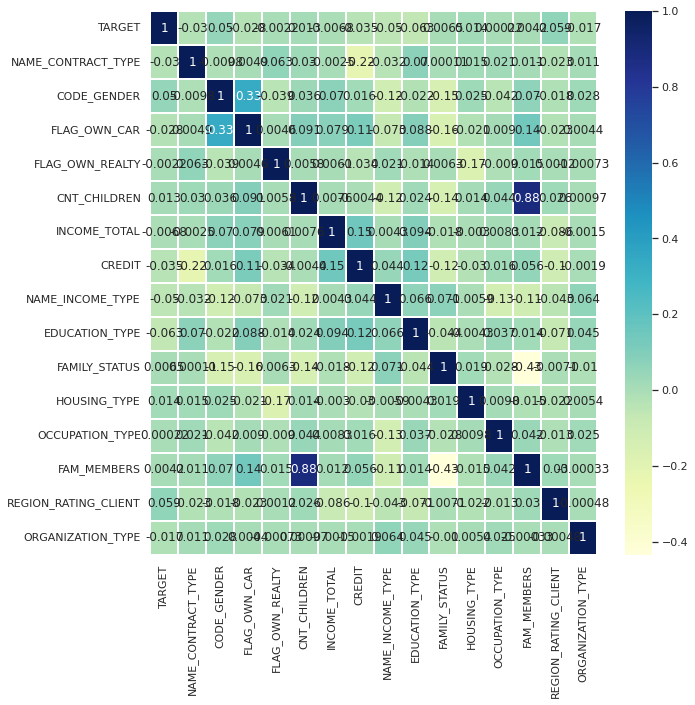

In [ ]:
ax = sns.heatmap(corr, annot=True, cmap="YlGnBu", linewidths=1)

#####**Interpreting the Correlation Matrix**

The correlation matrix signifies the variables that are effected with change in the target variable which suggests that a correlation exists, for variables such as ,

1.   A positive but weak correlation with region client rating where people living in higher rated areas are more defaulters perhaps given the expenses
2.    A positive but weak correlation with the children count where more children would suggest more areas to spend instead of returning back the loan
3.  A negative correlation with income total and credit, which also suggests lower the income the lower the target variable meaning leaning to defaulter.
4. A negative correlation with education, which means higher educated people would not be a defaulter.



#**The Covariance Matrix**



In [ ]:
cov = copy.cov()
cov

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
TARGET,0.077391,-0.002434,0.006676,-0.003747,-0.000284,0.002584,-4.588408e+02,-3.946290e+03,-0.013450,-0.023392,0.002112,0.002918,0.000202,0.001078,0.008573,-0.047838
NAME_CONTRACT_TYPE,-0.002434,0.084678,-0.001364,0.000677,0.008519,0.006438,-1.745461e+02,-2.586247e+04,-0.009038,0.027198,0.000037,0.003103,0.020224,0.002850,-0.003399,0.032134
CODE_GENDER,0.006676,-0.001364,0.227853,0.076191,-0.008587,0.012598,8.132251e+03,3.045106e+03,-0.054102,-0.014016,-0.085126,0.008881,-0.064613,0.030666,-0.004337,0.133246
FLAG_OWN_CAR,-0.003747,0.000677,0.076191,0.227647,0.001024,0.031959,9.120923e+03,2.140705e+04,-0.033493,0.055975,-0.087408,-0.007371,0.013986,0.061819,-0.005630,0.020971
FLAG_OWN_REALTY,-0.000284,0.008519,-0.008587,0.001024,0.215400,0.001957,6.882691e+02,-6.375286e+03,0.009397,-0.008432,0.003416,-0.057967,-0.013518,0.006265,0.000298,-0.003337
CNT_CHILDREN,0.002584,0.006438,0.012598,0.031959,0.001957,0.537495,1.348505e+03,-1.312959e+03,-0.083606,0.023639,-0.123635,0.007401,0.105027,0.596589,0.009826,0.007206
INCOME_TOTAL,-458.840819,-174.546113,8132.251436,9120.923006,688.269073,1348.504931,5.898660e+10,1.514985e+10,1014.772260,30308.483326,-5048.057932,-536.319493,6507.507700,2674.163952,-10795.919421,-3844.471200
CREDIT,-3946.290369,-25862.468456,3045.106498,21407.046938,-6375.285896,-1312.958843,1.514985e+10,1.645534e+11,17006.152090,65483.117666,-54919.571733,-9004.827074,21275.416385,21024.399608,-21894.760428,-7420.901767
NAME_INCOME_TYPE,-0.013450,-0.009038,-0.054102,-0.033493,0.009397,-0.083606,1.014772e+03,1.700615e+04,0.925691,0.083985,0.079197,-0.004149,-0.405444,-0.101863,-0.021272,0.550601
EDUCATION_TYPE,-0.023392,0.027198,-0.014016,0.055975,-0.008432,0.023639,3.030848e+04,6.548312e+04,0.083985,1.767739,-0.067474,-0.004157,0.158137,0.017104,-0.048997,0.596779


##### **Interpreting the Covariance Matrix**

The covariance matrix can be used to determine the direction of the relationship(linear) between two variables/attributes.
<ul>
<li>If there is a direct relationship between the variables, they will either decrease on increase together. Their coefficient will also be positive.</li>
<li>If the existing relationship that exists between them is of inverse nature, i.e. one variable decreases and the other increases, then the coefficient will be negative.</li>
</ul>
As seem from the covariance matrix above, each point in the table is a coefficient for the relationship between two of those attributes (xi, xj). If the value is positive, there exists a positive correlation. If both the attributes tend to decrease together the coefficient is negative.

# **More Visualizations**

In the intial portion of the EDA we used a simple set of graphs to see the structure and composition of our data, in the part below, we have used visualizations to show case more meaningful analysis and relations in the dataset.

## **Target Groupby Gender**

By using the below written code, we were able to group the defaulters and non-defaulters by their gender and find out how many defaulters and non-defaulters were present in both the gender categories.

In [ ]:
TargetBasedOnGender = pd.DataFrame(df.iloc[:, [0,2]]).groupby(['TARGET', 'CODE_GENDER']).size()
TargetGenderDf = TargetBasedOnGender.to_frame(name = 'size').reset_index()

names = ['F-Non-Defaulter', 'F-Defaulter', 'M-Non-Defaulter', 'M-Defaulter']
count = TargetGenderDf['size'].tolist()

output = pd.DataFrame(columns=['Type', 'Count'])

for i in range(len(names)):
  output = output.append({'Type': names[i], 'Count': count[i]}, ignore_index=True)

In [ ]:
TargetGenderDf

,TARGET,CODE_GENDER,size
0,0,F,175304
1,0,M,91881
2,1,F,14060
3,1,M,10613


In [ ]:
output

,Type,Count
0,F-Non-Defaulter,175304
1,F-Defaulter,91881
2,M-Non-Defaulter,14060
3,M-Defaulter,10613


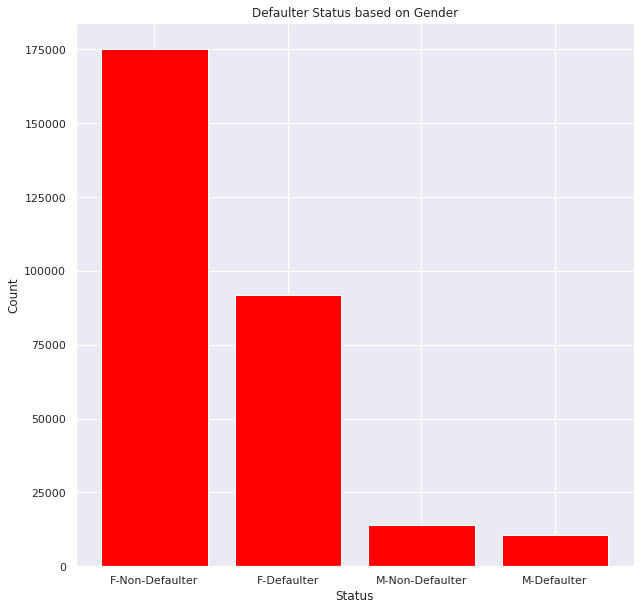

In [ ]:
labels = output['Type']
freq = output['Count']

plt.bar(labels, freq, color='red')
plt.title('Defaulter Status based on Gender')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

##### **Interpreting the Results**

From the graph above we can see that the number of female defaulters is very large compared to the male defaulters. One major reason for this is that the number of females in the original dataset is twice the number of males, there exists a gender inbalance in the data set. One way to deal with this would be to randomly select equal number of males and females from the dataset and then perform the analysis on that data.

#**Target based on Credit Loan Amount**

In [ ]:
minAmountCreditLoan = df['CREDIT'].min()
minAmountCreditLoan

45000.0

In [ ]:
maxAmountCreditLoan = df['CREDIT'].max()
maxAmountCreditLoan

4050000.0

In [ ]:
modeAmountCreditLoan = df['CREDIT'].mode()
modeAmountCreditLoan

0    450000.0
dtype: float64

In [ ]:
meanAmountCreditLoan = df['CREDIT'].mean()
meanAmountCreditLoan

604781.1796147441

<b>1.</b> Making a data frame and isolating the required variables, i.e. the Target Variable and the Credit Variable. The data is then sorted based on the Credit loan amount so that it can be split later where ever needed.

In [ ]:
targetCredit = pd.DataFrame(df.iloc[:, [0,7]]).sort_values(by='CREDIT',ascending=True)

<b>2.</b> The data frame is now split into two parts, the top part contains all the data points that have a credit amount that is below mean and the lower part contains all the data points that have a credit amount that is greater than the mean amount of the attribute.

In [ ]:
less, more = targetCredit[targetCredit['CREDIT'] < meanAmountCreditLoan], targetCredit[targetCredit['CREDIT'] >= meanAmountCreditLoan]

In [ ]:
less

,TARGET,CREDIT
72063,0,45000.0
213085,0,45000.0
13378,0,45000.0
20791,0,45000.0
264442,0,45000.0
...,...,...
120032,1,604683.0
98426,0,604683.0
142289,0,604683.0
186155,0,604683.0


In [ ]:
more

,TARGET,CREDIT
175577,0,604993.5
63738,0,604993.5
255209,0,605088.0
193518,1,605439.0
258014,0,605439.0
...,...,...
288455,0,4050000.0
17948,0,4050000.0
119681,0,4050000.0
14852,0,4050000.0


<b>3.</b> The data is then grouped based on their status as a defaulter/non-defaulter and their frequency is recorded for both the above split data frames.

In [ ]:
lessDf = less.groupby(['TARGET']).size().to_frame(name = 'size').reset_index()

lessNames = ['Non-Defaulter', 'Defaulter']
lessCount = lessDf['size'].tolist()
lessOutput = pd.DataFrame(columns=['Status', 'Count'])

for i in range(len(lessNames)):
  lessOutput = lessOutput.append({'Status': lessNames[i], 'Count': lessCount[i]}, ignore_index=True)

In [ ]:
lessDf

,TARGET,size
0,0,157885
1,1,16119


In [ ]:
lessOutput

,Status,Count
0,Non-Defaulter,157885
1,Defaulter,16119


In [ ]:
moreDf = more.groupby(['TARGET']).size().to_frame(name = 'size').reset_index()

moreNames = ['Non-Defaulter', 'Defaulter']
moreCount = moreDf['size'].tolist()
moreOutput = pd.DataFrame(columns=['Status', 'Count'])

for i in range(len(moreNames)):
  moreOutput = moreOutput.append({'Status': moreNames[i], 'Count': moreCount[i]}, ignore_index=True)

In [ ]:
moreDf

,TARGET,size
0,0,109300
1,1,8554


In [ ]:
moreOutput

,Status,Count
0,Non-Defaulter,109300
1,Defaulter,8554


<b>4.</b> The data from both the frames is now plotted for comparison.

In [ ]:
labels = moreOutput['Status']
mfreq = moreOutput['Count']
lfreq = lessOutput['Count']

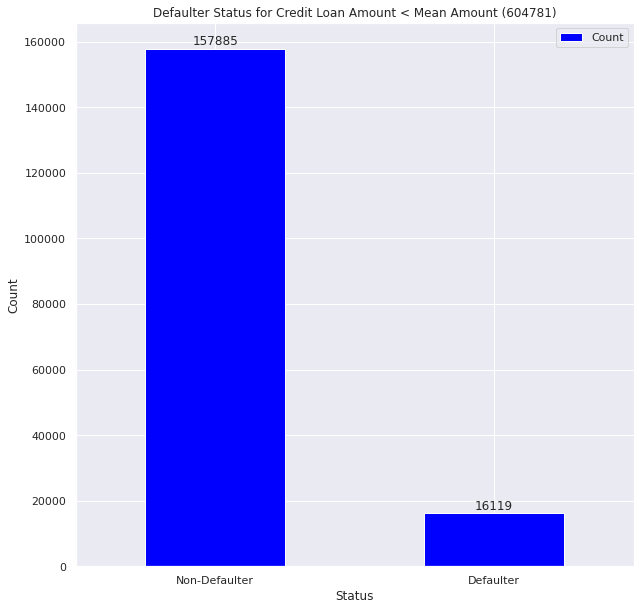

In [ ]:
ax = lessOutput.plot(kind='bar', rot=0, color="blue")
ax.set_title("Defaulter Status for Credit Loan Amount < Mean Amount (604781)", y = 1)
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_xticklabels(('Non-Defaulter', 'Defaulter'))
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 1
    label = "{:.0f}".format(y_value)
    ax.annotate(label, (x_value, y_value), xytext=(0, space), textcoords="offset points", ha='center', va='bottom')
plt.show()

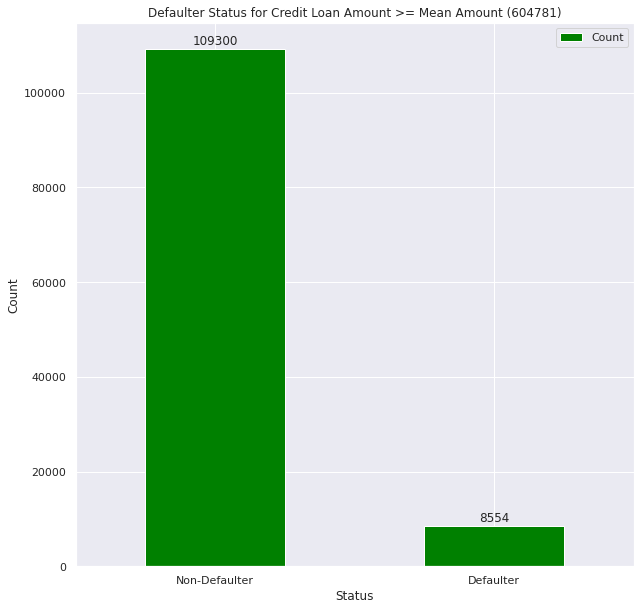

In [ ]:
ax = moreOutput.plot(kind='bar', rot=0, color="green")
ax.set_title("Defaulter Status for Credit Loan Amount >= Mean Amount (604781)", y = 1)
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_xticklabels(('Non-Defaulter', 'Defaulter'))
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 1
    label = "{:.0f}".format(y_value)
    ax.annotate(label, (x_value, y_value), xytext=(0, space), textcoords="offset points", ha='center', va='bottom')
plt.show()

#### **Interpreting the Results**

The data was split into two parts based on the Credit loan amount being less or more than the mean Credit Amount. Mean was just one the metrics that could have been used as a pivot to perform the split. The data could have also been plotted based on the mode amount, however since the Credit variable was continuous and not discrete using the mode would have meant a very large number of bar plots.

From the above results:
  > For Credit loan < 604781,   # Defaulters = 16,119<br>
  For Credit loan >= 604781,  # Defaulters = 8554
  >

It is surprising to note, that for a greater amount of credit loan, the number of defaulters dropped to approximately half of those who took out a smaller loan. However, it still can not be concluded that people with higher credit loan are less likely to become defaulters.



#**Target based on Occupation Type**

In [ ]:
targetOcc = pd.DataFrame(df.iloc[:, [0,12]])
occ = targetOcc.groupby(['TARGET','OCCUPATION_TYPE']).size().to_frame(name = 'size').reset_index()

In [ ]:
nondefaulterOcc = occ[occ['TARGET'] == 0]
defaulterOcc = occ[occ['TARGET'] == 1]

In [ ]:
nondefaulterOcc

,TARGET,OCCUPATION_TYPE,size
0,0,Accountants,9300
1,0,Cleaning staff,4193
2,0,Cooking staff,5307
3,0,Core staff,25660
4,0,Drivers,16138
5,0,HR staff,527
6,0,High skill tech staff,10648
7,0,IT staff,490
8,0,Laborers,125952
9,0,Low-skill Laborers,1726


In [ ]:
defaulterOcc

,TARGET,OCCUPATION_TYPE,size
18,1,Accountants,474
19,1,Cleaning staff,447
20,1,Cooking staff,621
21,1,Core staff,1738
22,1,Drivers,2095
23,1,HR staff,36
24,1,High skill tech staff,701
25,1,IT staff,34
26,1,Laborers,11994
27,1,Low-skill Laborers,359


#####**Defaulter Job Occupations**

In [ ]:
defaultersDataFrame = defaulterOcc.iloc[:,[1,2]]
defaultersDataFrame

,OCCUPATION_TYPE,size
18,Accountants,474
19,Cleaning staff,447
20,Cooking staff,621
21,Core staff,1738
22,Drivers,2095
23,HR staff,36
24,High skill tech staff,701
25,IT staff,34
26,Laborers,11994
27,Low-skill Laborers,359


#####**Non-Defaulters Job Occupations**

In [ ]:
nondefaultersDataFrame = nondefaulterOcc.iloc[:,[1,2]]
nondefaultersDataFrame

,OCCUPATION_TYPE,size
0,Accountants,9300
1,Cleaning staff,4193
2,Cooking staff,5307
3,Core staff,25660
4,Drivers,16138
5,HR staff,527
6,High skill tech staff,10648
7,IT staff,490
8,Laborers,125952
9,Low-skill Laborers,1726


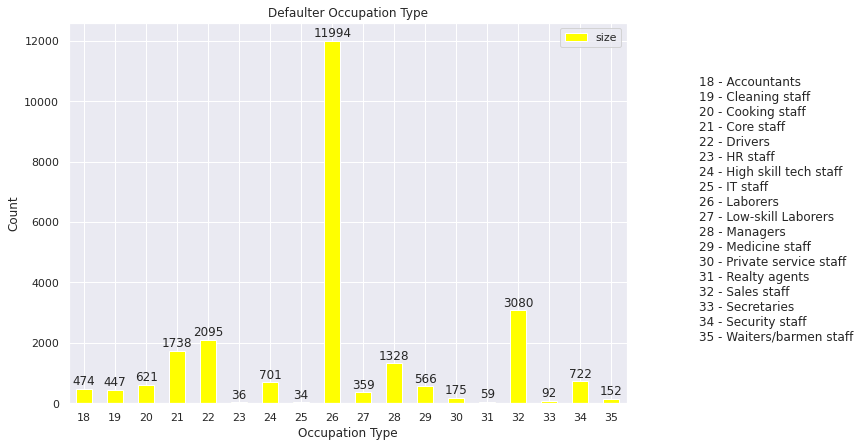

In [ ]:
x_legend = '\n'.join(f'{n} - {name}' for n,name in zip(defaultersDataFrame.index,defaultersDataFrame['OCCUPATION_TYPE']))
ax = defaultersDataFrame.plot(kind='bar', rot=0, color="yellow", figsize=(10, 7))
ax.set_title("Defaulter Occupation Type", y = 1)
ax.set_xlabel('Occupation Type')
ax.set_ylabel('Count')
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 1
    label = "{:.0f}".format(y_value)
    ax.annotate(label, (x_value, y_value), xytext=(0, space), textcoords="offset points", ha='center', va='bottom')
t = ax.text(1,0.25,x_legend,transform=ax.figure.transFigure)
plt.show()

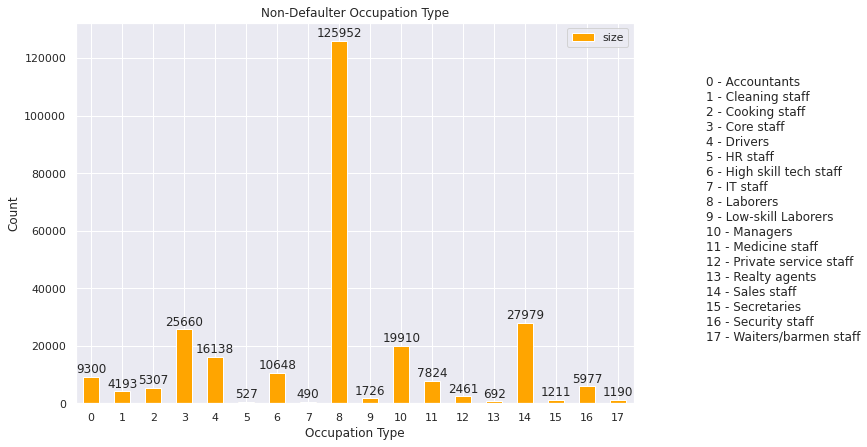

In [ ]:
x_legend = '\n'.join(f'{n} - {name}' for n,name in zip(nondefaultersDataFrame.index,nondefaultersDataFrame['OCCUPATION_TYPE']))
ax = nondefaultersDataFrame.plot(kind='bar', rot=0, color="orange", figsize=(10, 7))
ax.set_title("Non-Defaulter Occupation Type", y = 1)
ax.set_xlabel('Occupation Type')
ax.set_ylabel('Count')
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 1
    label = "{:.0f}".format(y_value)
    ax.annotate(label, (x_value, y_value), xytext=(0, space), textcoords="offset points", ha='center', va='bottom')
t = ax.text(1,0.25,x_legend,transform=ax.figure.transFigure)
plt.show()

In [ ]:
dfo = pd.DataFrame(df['OCCUPATION_TYPE'].value_counts())
dfo

,OCCUPATION_TYPE
Laborers,137946
Sales staff,31059
Core staff,27398
Managers,21238
Drivers,18233
High skill tech staff,11349
Accountants,9774
Medicine staff,8390
Security staff,6699
Cooking staff,5928


Text(0, 0.5, 'Count')

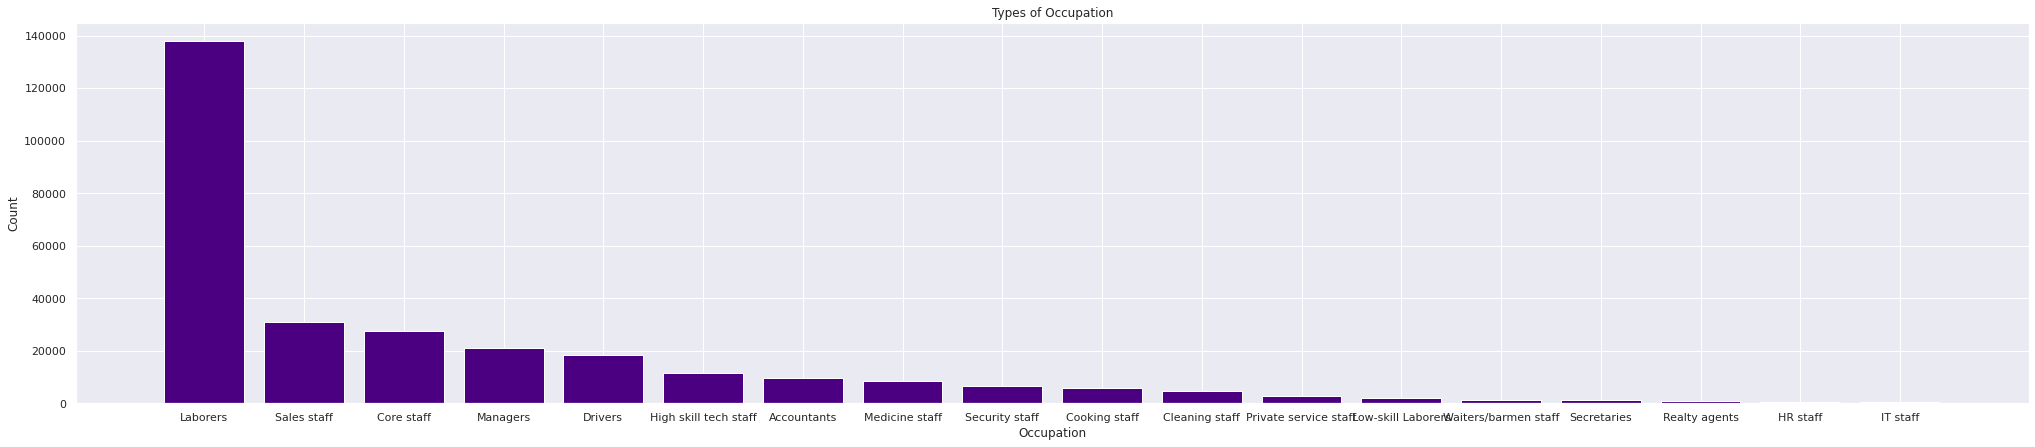

In [ ]:
fig = plt.figure(figsize =(35, 7))
plt.bar(dfo.index.tolist(), dfo['OCCUPATION_TYPE'], color='indigo')
plt.title('Types of Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')

####**Interpreting the Results**

From the above graph we can see that Laborers are the most frequent occupation type in the data set and IT-Staff being the least common. And hence laborers have the highest Defaulter to Non-Defaulter ration in the entire data set. One reason for laborers having higher numbers in defaulters is that they might be earning less compared to other professions generally. The below code compares the mean for the income of the Laborers and then for the entire data set excluding the Laborers.

In [ ]:
minLab = df[df['OCCUPATION_TYPE'] == 'Laborers']['INCOME_TOTAL'].min()
meanLab = df[df['OCCUPATION_TYPE'] == 'Laborers']['INCOME_TOTAL'].mean()

overallmin = df[df['OCCUPATION_TYPE'] != 'Laborers']['INCOME_TOTAL'].min()
overallmean = df[df['OCCUPATION_TYPE'] != 'Laborers']['INCOME_TOTAL'].mean()

print('Overall Mean of Data Excluding Laborers: ', overallmean)
print('Overall Minimum Income Total Excluding Laborers: ', overallmin)

print('\nMean Income Total for Laborers: ', meanLab)
print('Minimum Income Total for Laborers: ', minLab)

Overall Mean of Data Excluding Laborers:  179600.6654234563
Overall Minimum Income Total Excluding Laborers:  25650.0

Mean Income Total for Laborers:  162017.42455221608
Minimum Income Total for Laborers:  25650.0


In [ ]:
lone = nondefaultersDataFrame['OCCUPATION_TYPE'].tolist()
ltwo = defaultersDataFrame['OCCUPATION_TYPE'].tolist()

In [ ]:
safe = set()
for i in lone:
  if i not in ltwo:
    safe.add(i)

In [ ]:
if len(safe) == 0:
  print('Empty List!')
else:
  print(safe)

Empty List!


From the above results, we can see that there is no single profession in the entire data set, which does not exist in the defaulters list.

#**Target V/S Type of Loan**

In [ ]:
targetLoanType = pd.DataFrame(df.iloc[:,[0,1]]).groupby(['TARGET', 'NAME_CONTRACT_TYPE']).size()
loanDf = targetLoanType.to_frame(name = 'size').reset_index()
loanDf

,TARGET,NAME_CONTRACT_TYPE,size
0,0,Cash loans,241519
1,0,Revolving loans,25666
2,1,Cash loans,23079
3,1,Revolving loans,1594


In [ ]:
nonDefaultersLoan = loanDf[loanDf['TARGET'] == 0]
defaultersLoan = loanDf[loanDf['TARGET'] == 1]

In [ ]:
nonDefaultersLoan

,TARGET,NAME_CONTRACT_TYPE,size
0,0,Cash loans,241519
1,0,Revolving loans,25666


In [ ]:
defaultersLoan

,TARGET,NAME_CONTRACT_TYPE,size
2,1,Cash loans,23079
3,1,Revolving loans,1594


In [ ]:
loanLabels = nonDefaultersLoan['NAME_CONTRACT_TYPE'].tolist()
loanLabels

['Cash loans', 'Revolving loans']

In [ ]:
sizeDefaulters = defaultersLoan['size'].tolist()
sizeNonDefaulters = nonDefaultersLoan['size'].tolist()

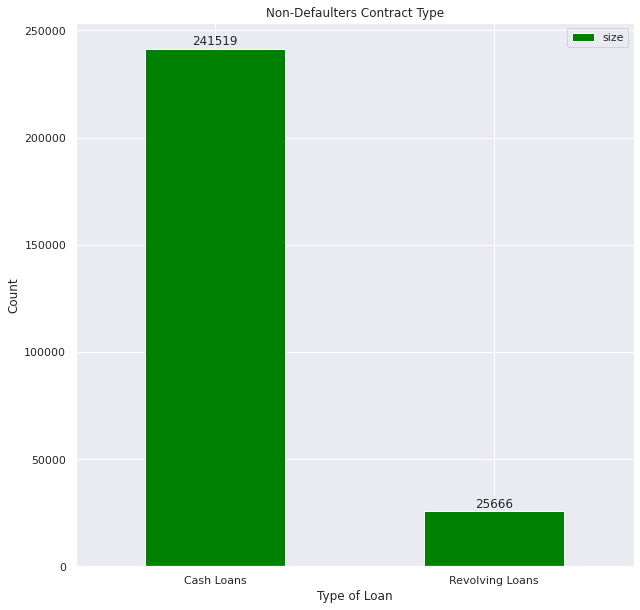

In [ ]:
ax = nonDefaultersLoan.iloc[:, [1,2]].plot(kind='bar', rot=0, color="green")
ax.set_title("Non-Defaulters Contract Type", y = 1)
ax.set_xlabel('Type of Loan')
ax.set_ylabel('Count')
ax.set_xticklabels(('Cash Loans', 'Revolving Loans'))
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 1
    label = "{:.0f}".format(y_value)
    ax.annotate(label, (x_value, y_value), xytext=(0, space), textcoords="offset points", ha='center', va='bottom')
plt.show()

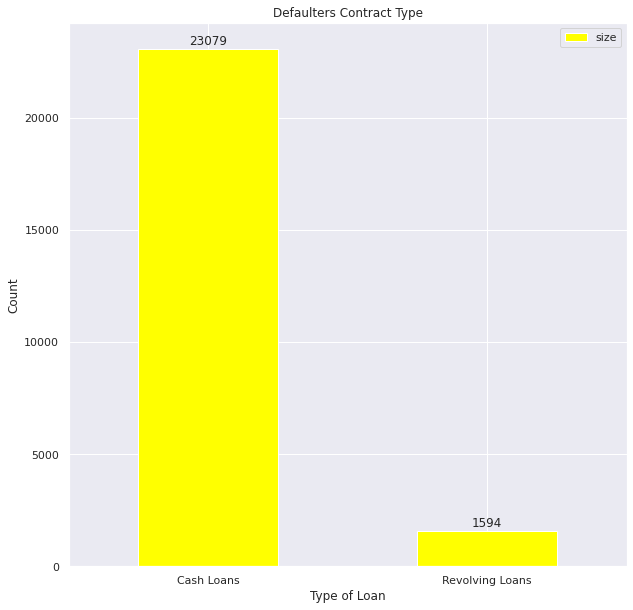

In [ ]:
ax = defaultersLoan.iloc[:, [1,2]].plot(kind='bar', rot=0, color="yellow")
ax.set_title("Defaulters Contract Type", y = 1)
ax.set_xlabel('Type of Loan')
ax.set_ylabel('Count')
ax.set_xticklabels(('Cash Loans', 'Revolving Loans'))
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 1
    label = "{:.0f}".format(y_value)
    ax.annotate(label, (x_value, y_value), xytext=(0, space), textcoords="offset points", ha='center', va='bottom')
plt.show()

In [ ]:
totalNum = pd.DataFrame(df['NAME_CONTRACT_TYPE'].value_counts())
totalNum

,NAME_CONTRACT_TYPE
Cash loans,264598
Revolving loans,27260


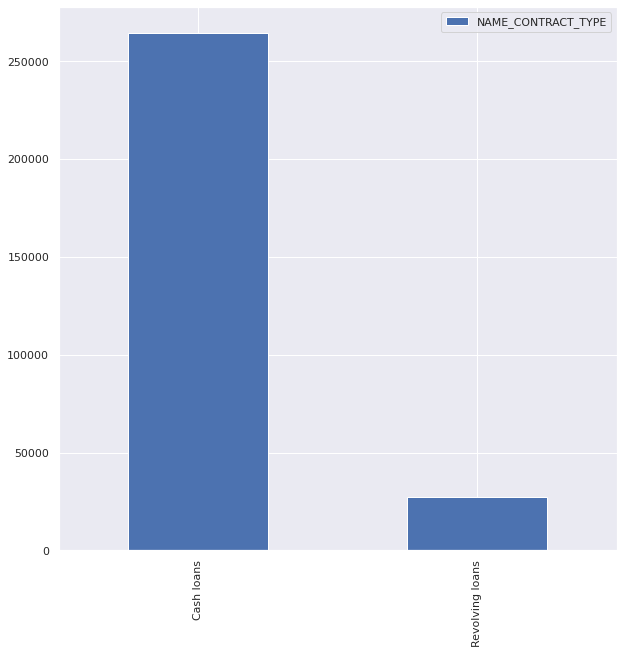

In [ ]:
totalNum.plot(kind='bar')

###**Interpreting the Results**

As seen from the graph and table above the number of cash loans is very large compared to the revolving loans.

In [ ]:
total = 291858
cash = 264598
revolving = 27260
print('The percentage of cash loans = ', cash/total)
print('The percentage of revolving loans = ', revolving/total)

The percentage of cash loans =  0.9065984142973638
The percentage of revolving loans =  0.09340158570263621


In [ ]:
print('The percentage for defaulters in cash loans = ', defaultersLoan['size'].tolist()[0]/cash)
print('The percentage for defaulters in revolving loans = ', defaultersLoan['size'].tolist()[1]/revolving)

The percentage for defaulters in cash loans =  0.08722288150326155
The percentage for defaulters in revolving loans =  0.05847395451210565


From, the data above we can see that there is a greater number of defaulters who use cash-loans compared to those who receive revolving loans.
It is also important to note, a significantly high percentage of the users opted for the cash loans instead of the revolving loans.  

In [ ]:
#@title
%%html
<marquee style='width: 30%; color: blue;'><b>End of Phase 1!</b></marquee>

In [ ]:
%%html
<img src = "https://www.verdict.co.uk/cardsinternational/wp-content/uploads/sites/3/2020/04/CCWorries.jpg">